In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [4]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print("Sex values:")
print(df["Sex"].value_counts())

print("\nEmbarked values:")
print(df["Embarked"].value_counts())

print("\nPclass values:")
print(df["Pclass"].value_counts())

Sex values:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked values:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Pclass values:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [8]:
print("Age range:", df["Age"].min(), "to", df["Age"].max())
print("Fare range:", df["Fare"].min(), "to", df["Fare"].max())
print("SibSp range:", df["SibSp"].min(), "to", df["SibSp"].max())
print("Parch range:", df["Parch"].min(), "to", df["Parch"].max())

Age range: 0.42 to 80.0
Fare range: 0.0 to 512.3292
SibSp range: 0 to 8
Parch range: 0 to 6


In [9]:
before_summary = {
    "Rows": len(df),
    "Columns": df.shape[1],
    "Duplicate Rows": df.duplicated().sum(),
    "Total Missing Values": df.isnull().sum().sum()
}

before_summary

{'Rows': 891,
 'Columns': 12,
 'Duplicate Rows': np.int64(0),
 'Total Missing Values': np.int64(866)}

## Missing Value Handling

The dataset contains missing values in the Age, Cabin, and Embarked columns.

**Age:** Missing values are replaced with the median age. The median is preferred because it is less affected by extreme values than the mean.

**Embarked:** Missing values are replaced with the most frequent value (mode), since this is a categorical variable.

**Cabin:** Missing values are replaced with "Unknown" rather than removing the column or rows. This preserves the passenger records while indicating that cabin information was not available.

In [10]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill missing Cabin values with "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [11]:
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 0


## Duplicate Removal

Duplicate rows were checked using the complete set of columns. Any exact duplicate records are removed because they represent repeated records rather than additional passenger information.

In [13]:
df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (891, 12)


## Data Standardization

Categorical columns were checked for inconsistent formatting. Values in the Sex and Embarked columns are standardized by removing extra spaces and applying consistent capitalization.

In [14]:
# Standardize Sex values
df["Sex"] = df["Sex"].str.strip().str.lower()

df["Sex"] = df["Sex"].replace({
    "male": "Male",
    "female": "Female"
})

# Standardize Embarked values
df["Embarked"] = df["Embarked"].str.strip().str.upper()

print("Sex values:")
print(df["Sex"].unique())

print("\nEmbarked values:")
print(df["Embarked"].unique())

Sex values:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Embarked values:
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


## Data Type Correction

The data types of the columns were checked and corrected where necessary. Passenger IDs and ticket numbers are identifiers, categorical information is stored as categorical data, and numerical variables are stored using appropriate numeric types.

In [17]:
# Correct data types

df["PassengerId"] = df["PassengerId"].astype("int64")
df["Survived"] = df["Survived"].astype("int64")
df["Pclass"] = df["Pclass"].astype("int64")

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["SibSp"] = pd.to_numeric(df["SibSp"], errors="coerce")
df["Parch"] = pd.to_numeric(df["Parch"], errors="coerce")
df["Fare"] = pd.to_numeric(df["Fare"], errors="coerce")

df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")



In [16]:
print(df.dtypes)

PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object


## Outlier Detection Using IQR

The Interquartile Range (IQR) method is used to identify potential outliers in numerical columns.

IQR is calculated as:

IQR = Q3 - Q1

Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

Outliers are not automatically removed because extreme values can represent genuine observations. They will be reviewed before deciding whether to retain or remove them.

In [18]:
numeric_columns = ["Age", "SibSp", "Parch", "Fare"]

outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    outlier_summary[column] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }

outlier_summary

{'Age': {'Q1': np.float64(22.0),
  'Q3': np.float64(35.0),
  'IQR': np.float64(13.0),
  'Lower Bound': np.float64(2.5),
  'Upper Bound': np.float64(54.5),
  'Outlier Count': 66},
 'SibSp': {'Q1': np.float64(0.0),
  'Q3': np.float64(1.0),
  'IQR': np.float64(1.0),
  'Lower Bound': np.float64(-1.5),
  'Upper Bound': np.float64(2.5),
  'Outlier Count': 46},
 'Parch': {'Q1': np.float64(0.0),
  'Q3': np.float64(0.0),
  'IQR': np.float64(0.0),
  'Lower Bound': np.float64(0.0),
  'Upper Bound': np.float64(0.0),
  'Outlier Count': 213},
 'Fare': {'Q1': np.float64(7.9104),
  'Q3': np.float64(31.0),
  'IQR': np.float64(23.0896),
  'Lower Bound': np.float64(-26.724),
  'Upper Bound': np.float64(65.6344),
  'Outlier Count': 116}}

## Outlier Handling Decision

The IQR method identified potential outliers in Age, SibSp, Parch, and Fare.

The identified values were reviewed rather than automatically removed. The outliers were retained because they may represent genuine passenger characteristics rather than data-entry errors.

For example, higher Fare values may represent legitimate first-class or premium tickets, while higher SibSp and Parch values may represent passengers travelling with larger families.

The Parch column produced a large number of potential outliers because its first and third quartiles are both 0. In this case, the IQR rule is not very informative because most passengers have a value of 0. Therefore, these observations were retained.

Keeping these values avoids unnecessarily removing valid information from the dataset.

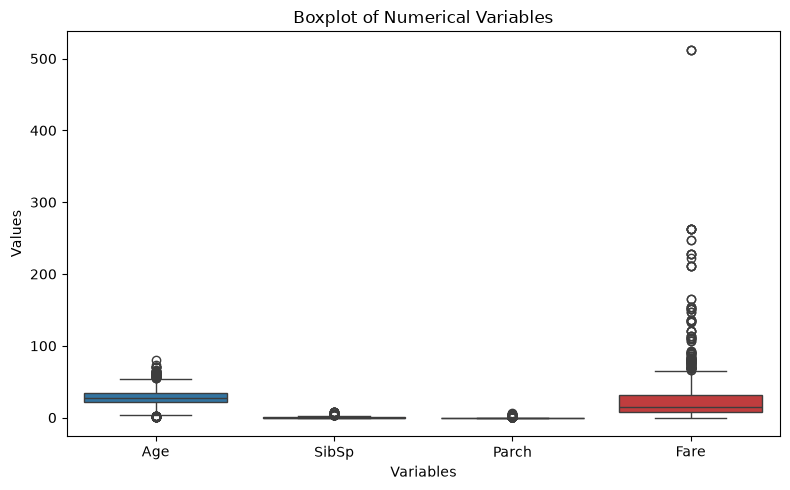

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df[["Age", "SibSp", "Parch", "Fare"]])

plt.title("Boxplot of Numerical Variables")
plt.xlabel("Variables")
plt.ylabel("Values")
plt.tight_layout()

plt.savefig("../images/numerical_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# After-cleaning quality information

after_missing = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()
after_rows = len(df)

print("After Cleaning")
print("----------------")
print("Rows:", after_rows)
print("Columns:", df.shape[1])
print("Total Missing Values:", after_missing)
print("Duplicate Rows:", after_duplicates)

After Cleaning
----------------
Rows: 891
Columns: 12
Total Missing Values: 0
Duplicate Rows: 0


In [21]:
before_rows = 891
before_duplicates = 0
before_missing = 866

In [22]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Column Count",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        before_rows,
        12,
        before_missing,
        before_duplicates
    ],
    "After Cleaning": [
        after_rows,
        df.shape[1],
        after_missing,
        after_duplicates
    ]
})

quality_summary

,Metric,Before Cleaning,After Cleaning
0,Row Count,891,891
1,Column Count,12,12
2,Total Missing Values,866,0
3,Duplicate Rows,0,0


In [23]:
print("Final Dataset Shape:", df.shape)

print("\nFinal Missing Values:")
print(df.isnull().sum())

print("\nFinal Data Types:")
print(df.dtypes)

Final Dataset Shape: (891, 12)

Final Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Final Data Types:
PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object


In [24]:
df.to_csv("../data/titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [25]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nCleaned Dataset Preview:")
display(df.head())

Final Dataset Shape: (891, 12)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Duplicate Rows: 0

Cleaned Dataset Preview:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,Unknown,S
